In [1]:
# Import required classes/functions from LangGraph
from langgraph.graph import StateGraph, START, END, add_messages

# Import typing helpers for state definition
from typing import TypedDict, Annotated, List

# Import memory saver for chat history
from langgraph.checkpoint.memory import MemorySaver

# Import Groq LLM model
from langchain_groq import ChatGroq

# Import Tavily search tool for web search
from langchain_community.tools import TavilySearchResults

# Import ToolNode to execute tools
from langgraph.prebuilt import ToolNode

# Import HumanMessage class
from langchain_core.messages import HumanMessage


# Create memory object to store conversation state
memory = MemorySaver()


# Create Tavily search tool with max 2 search results
search_tool = TavilySearchResults(max_results=2)

# Put tools into a list
tools = [search_tool]


# Initialize Groq LLM model
llm = ChatGroq(model="llama-3.1-8b-instant")

# Bind tools to the LLM so it can use them
llm_with_tools = llm.bind_tools(tools=tools)


# Define the state structure
class BasicState(TypedDict):

    # Store messages list and auto-add new messages
    messages: Annotated[List, add_messages]


# Function to call the model
def model(state: BasicState):

    # Send messages to LLM and return response
    return {
        "messages": [llm_with_tools.invoke(state["messages"])]
    }


# Function to decide whether tool is needed
def tools_router(state: BasicState):

    # Get last message from state
    last_message = state["messages"][-1]

    # Check if model requested any tool calls
    if (
        hasattr(last_message, "tool_calls") and
        len(last_message.tool_calls) > 0
    ):

        # Go to tools node
        return "tools"

    else:

        # End graph if no tools needed
        return END


# Create graph object with BasicState
graph = StateGraph(BasicState)

# Add model node
graph.add_node("model", model)

# Add tools node
graph.add_node("tools", ToolNode(tools=tools))


# Set starting point of graph
graph.set_entry_point("model")

# Add conditional routing after model execution
graph.add_conditional_edges("model", tools_router)

# After tool execution, go back to model
graph.add_edge("tools", "model")


# Compile graph with memory and pause before tools
app = graph.compile(
    checkpointer=memory,
    interrupt_before=["tools"]
)

c:\Users\HP\Desktop\Jupyter Notebooks\Projects\LangGraph\venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1
C:\Users\HP\AppData\Local\Temp\ipykernel_6320\566864823.py:28: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search_tool = TavilySearchResults(max_results=2)


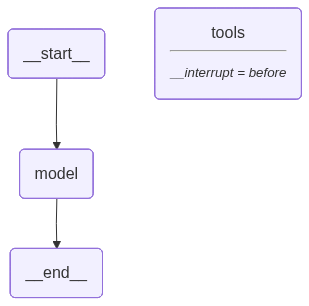

In [2]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [3]:
# Create configuration dictionary
config = {
    "configurable": {

        # Unique thread ID to maintain conversation memory
        "thread_id": 1
    }
}


# Start streaming graph execution
events = app.stream(

    # Input state containing user message
    {
        "messages": [
            HumanMessage(
                content="What is the current weather in Hikkaduwa?"
            )
        ]
    },

    # Pass config (thread_id for memory)
    config=config,

    # Stream outputs step-by-step
    stream_mode="values"
)


# Loop through streamed events
for event in events:

    # Print the latest message nicely
    event["messages"][-1].pretty_print()

================================ Human Message =================================

What is the current weather in Hikkaduwa?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (2287q16qr)
 Call ID: 2287q16qr
  Args:
    query: Hikkaduwa current weather


In [4]:
events = app.stream(None, config, stream_mode="values")
for event in events:
    event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (2287q16qr)
 Call ID: 2287q16qr
  Args:
    query: Hikkaduwa current weather
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Weather - Hikkaduwa - 14-Day Forecast & Rain | Ventusky", "url": "https://www.ventusky.com/6.14;80.1", "content": "| rain, thunderstorms likely 26 °C 1 mm 70 %  NW  6 km/h | overcast 27 °C 0.1 mm 70 %  NW  8 km/h | mostly cloudy 27 °C 0 mm 50 %  NW  7 km/h | overcast 27 °C 0.1 mm 80 %  W  9 km/h | mixed with rain showers 28 °C 0.2 mm 90 %  W  11 km/h | mixed with rain showers 29 °C 0.2 mm 90 %  W  13 km/h | mixed with rain showers 29 °C 0.2 mm 90 %  W  15 km/h | mixed with rain showers 29 °C 0.3 mm 90 %  W  16 km/h | rain, thunderstorms likely 29 °C 1 mm 90 %  W  15 km/h | rain, thunderstorms likely 29 °C 1 mm 90 %  W  15 km/h | rain, thunderstorms likely 28 °C 0.7 